# Final Project: Comparing Greenhouse Effects on Venus, Earth, and Mars

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8") # looked it up after the seaborn lecture because i liked that the plots looked more professional

In [2]:
earth_profile = pd.DataFrame({
    "alt_km": [0,1,2,3,4,5,6,7,8,9,10,12,14,16,18,20,22,24,26,28,30],
    "temp_K": [288.15,281.65,275.15,268.65,262.15,255.65,249.15,242.65,236.15,229.65,
               223.15,216.65,216.65,216.65,216.65,216.65,218.65,220.65,222.65,224.65,226.65],
    "pres_Pa": [101325,89875,79495,70108,61660,54048,47181,40999,35430,30400,
                25899,19399,14699,11299,8699,6749,5259,4109,3219,2529,1999]
})
earth_profile["planet"] = "Earth" 

# creating a dataframe of the earth's atmosphere-at-a-glance, including altitude, temperature, and pressure.
# Will compare how temperature and pressure vary with altitude across the three planets. 
# Data taken from NASA archives and streamlined to the variables we wanted to focus on. 

In [3]:
venus_profile = pd.DataFrame({
    "alt_km": [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70],
    "temp_K": [737,700,660,620,580,540,500,460,420,380,340,300,260,220,180],
    "pres_Pa": [9.2e6,6.5e6,4.5e6,3.0e6,1.8e6,1.0e6,6e5,3e5,1.5e5,7e4,3e4,1e4,3e3,1e3,300]
})
venus_profile["planet"] = "Venus"
# same as above but for venus (note that we are not using astropy and instead just have units in column names

In [4]:
mars_profile = pd.DataFrame({
    "alt_km": [0,2,4,6,8,10,12,14,16,18,20,25,30,35,40,45,50],
    "temp_K": [215,210,205,200,195,190,185,180,175,170,165,160,155,150,145,140,135],
    "pres_Pa": [610,500,410,330,260,200,150,110,80,60,45,20,10,5,3,2,1]
})
mars_profile["planet"] = "Mars"
# same again but for Mars

In [5]:
df_profiles = pd.concat([earth_profile, venus_profile, mars_profile], ignore_index=True)
df_profiles
# groups all three into one large dataframe so that we can manipulate and plot the data altogether 

,alt_km,temp_K,pres_Pa,planet
0,0,288.15,101325.0,Earth
1,1,281.65,89875.0,Earth
2,2,275.15,79495.0,Earth
3,3,268.65,70108.0,Earth
4,4,262.15,61660.0,Earth
5,5,255.65,54048.0,Earth
6,6,249.15,47181.0,Earth
7,7,242.65,40999.0,Earth
8,8,236.15,35430.0,Earth
9,9,229.65,30400.0,Earth


In [6]:
df_profiles.shape

(53, 4)

In [7]:
df_profiles.head()

,alt_km,temp_K,pres_Pa,planet
0,0,288.15,101325.0,Earth
1,1,281.65,89875.0,Earth
2,2,275.15,79495.0,Earth
3,3,268.65,70108.0,Earth
4,4,262.15,61660.0,Earth


In [8]:
df_profiles.columns

Index(['alt_km', 'temp_K', 'pres_Pa', 'planet'], dtype='object')

In [9]:
planet_constants = pd.DataFrame({
    "planet": ["Venus", "Earth", "Mars"],
    "albedo": [0.77, 0.306, 0.25],                 # NASA
    "solar_flux_Wm2": [2613.9, 1361, 586.2],       # NASA SORCE/TIM
    "effective_temp_K": [226, 255, 210],           # NASA
    "surface_temp_K": [737, 288, 210],             # NASA
    "co2_fraction": [0.965, 0.0004, 0.953],        # NASA
    "n2_fraction": [0.035, 0.78, 0.027],           # NASA
    "surface_pressure_Pa": [9.2e6, 101325, 610],   # NASA
})
planet_constants

# again, rather than using astropy, sought out constant values such as each planet's average surface temp to use in more simple comparisons

,planet,albedo,solar_flux_Wm2,effective_temp_K,surface_temp_K,co2_fraction,n2_fraction,surface_pressure_Pa
0,Venus,0.770,2613.9,226,737,0.9650,0.035,9200000.0
1,Earth,0.306,1361.0,255,288,0.0004,0.780,101325.0
2,Mars,0.250,586.2,210,210,0.9530,0.027,610.0


In [10]:
planet_constants["greenhouse_gap_K"] = (
    planet_constants["surface_temp_K"] - planet_constants["effective_temp_K"]
)
planet_constants
# creating a new column, "greenhouse gap" that models the effect on the temperature by comparing actual to predicted

,planet,albedo,solar_flux_Wm2,effective_temp_K,surface_temp_K,co2_fraction,n2_fraction,surface_pressure_Pa,greenhouse_gap_K
0,Venus,0.770,2613.9,226,737,0.9650,0.035,9200000.0,511
1,Earth,0.306,1361.0,255,288,0.0004,0.780,101325.0,33
2,Mars,0.250,586.2,210,210,0.9530,0.027,610.0,0


In [11]:
planet_constants["emissivity"] = (
    (planet_constants["effective_temp_K"] / planet_constants["surface_temp_K"]) ** 4
)
planet_constants
# calculating emissivity based on the Stefan-Boltzmann Law and adding to the dataframe

,planet,albedo,solar_flux_Wm2,effective_temp_K,surface_temp_K,co2_fraction,n2_fraction,surface_pressure_Pa,greenhouse_gap_K,emissivity
0,Venus,0.770,2613.9,226,737,0.9650,0.035,9200000.0,511,0.008842
1,Earth,0.306,1361.0,255,288,0.0004,0.780,101325.0,33,0.614597
2,Mars,0.250,586.2,210,210,0.9530,0.027,610.0,0,1.000000


In [12]:
planet_constants.shape

(3, 10)

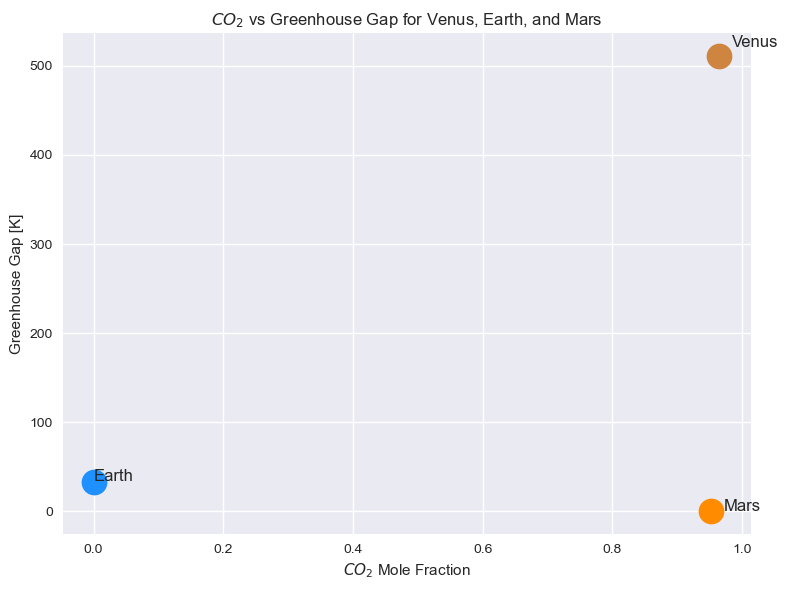

In [14]:
colors = {
    "Mars": "darkorange",
    "Earth": "dodgerblue",
    "Venus": "peru"   # permanently assigning colors to planet names
}

plt.figure(figsize=(8,6))
# have to use a for loop since I want each data point to be in a different, SPECIFIC color/ associated with a different planet
for i, row in planet_constants.iterrows():
    plt.scatter(
        row["co2_fraction"],
        row["greenhouse_gap_K"],
        s=300,
        color=colors[row["planet"]],
        linewidth=1.2
    )
    plt.text(
        row["co2_fraction"] * 1.02,
        row["greenhouse_gap_K"] * 1.02,
        row["planet"],
        fontsize=12
    ) # adds label to the scatter plot dot rather than needing a legend, but the 1.02 is supposed to make it not overlap/ overlap less with the dot.
"""
Plot greenhouse gap vs CO2.
The idea is to demonstrate how the amount of CO2 in a planet's atmosphere contributes to the greenhouse effect.
However, this is the CO2 fraction, hence why Mars is both far on the right for having a very high fraction but low in height because
despite a high fraction it has a low concentration/ very thin atmosphere and essentially nonexistent greenhouse effect.
The theory is that in the (distant) past, Mars had a reverse greenhosue effect which basically accounts for why it looks like no effect now.
The greenhouse effect's intensity depends on the amount of CO2, so this has the nuance of both fraction and potency. 
"""


plt.xlabel("$CO_2$ Mole Fraction")
plt.ylabel("Greenhouse Gap [K]")
plt.title("$CO_2$ vs Greenhouse Gap for Venus, Earth, and Mars")
plt.tight_layout()
plt.savefig('final_project_CO2_subplot.png') # want this to automatically pop up as a separate png file rather than take screenshot
plt.show()


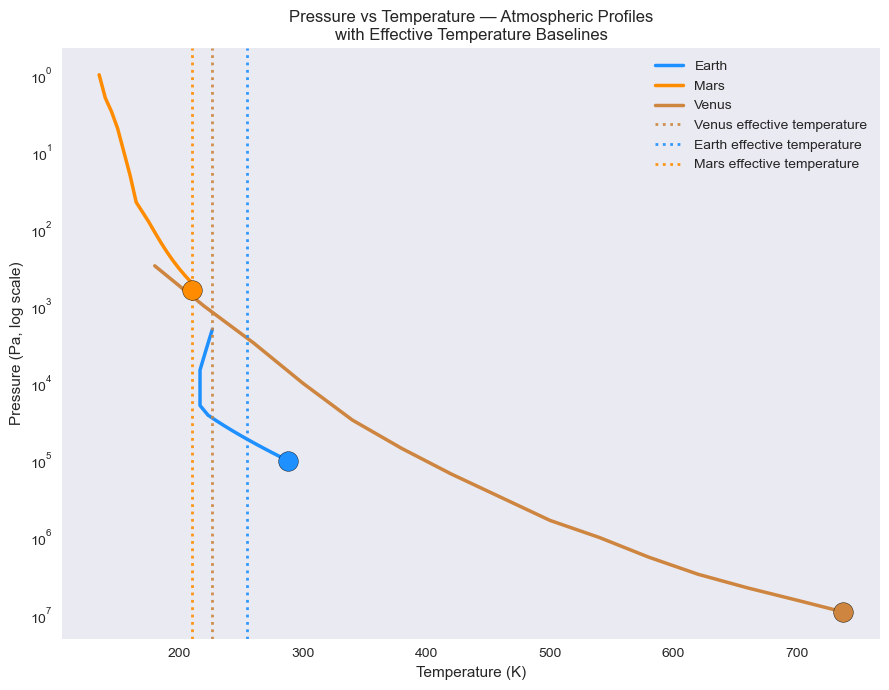

In [15]:
plt.figure(figsize=(9,7))
# Bigger Figsize than normal because we want to plot many different things at once (and Venus' values are so large compared to Mars and Earth.
# Don't want to squish smaller values or lose precision so we need a bigger plot


# Row by row plotting from the concatenated profiles df to be able to assign each color to each unique planet line plot
for planet, g in df_profiles.groupby("planet"):
    plt.plot(
        g["temp_K"],
        g["pres_Pa"],
        label=planet,
        color=colors[planet],
        linewidth=2.5
    )
"""
Plot temperature vs pressure for each planet.
The idea is to demonstrate how heat is distributed through the atmosphere.
Pressure is proportional to atmospheric mass anyway, so pressure is a good choice (vs the linear altitude that doesn't necessarily reveal much)
The greenhouse effect's intensity depends on the pressure, so this plot would indicate its strength
"""

# Add surface temperature markers (circles)
for planet, row in planet_constants.set_index("planet").iterrows():
    plt.scatter(
        row["surface_temp_K"],
        row["surface_pressure_Pa"],
        s=200,
        color=colors[planet],
        edgecolor="black",
        zorder=5
    )
"""
Marks the actual surface conditions. Essentially replicating the "greenhouse_gap_K" column by representing the difference between actual and effective temperatures. 
Again, going row by row to assign a unique color (defined earlier in the 'qualitative' plots) per planet.
Want a larger marker than the size of the line to represent the planet's surface temperature. 
zorder is meant to put the markers on top of the lines in the graph (kind of like the ordering of elements/ send to forward in google slides)
"""

# Add vertical dotted lines for effective temperature
for planet, row in planet_constants.set_index("planet").iterrows():
    effT = row["effective_temp_K"]
    plt.axvline(
        x=effT,
        color=colors[planet],
        label = f"{planet} effective temperature",
        linestyle="dotted",
        linewidth=2,
        alpha=0.9
    )

"""
Marks the effective temperature. Essentially replicating the "greenhouse_gap_K" column by representing the difference between actual and effective temperatures. 
Again, going row by row to assign a unique color (defined earlier in the 'qualitative' plots) per planet.
Want a dotted vertical line to represent the effective temperature because there is technically no standard pressure associated with this value (assumed surface pressure, but still).
Effective temperature Teff is defined by the energy balance:
 (1 - albedo) * S / 4 = σ * Teff^4
It is the temperature the planet WOULD have with NO atmosphere.
The horizontal distance between this line and the surface point is a result of the greenhouse effect.
"""

# Log pressure axis
plt.yscale("log")
plt.gca().invert_yaxis()

"""
Pressure spans many orders of magnitude because pressure differences, even within a single planet's atmosphere, are large. 
This way, we can see all three planets in one chart instead of having to make three separate plots with different axes scales, making it easier to compare.
We also inverted the pressure, since it decreases with altitude, so that the graph mimics an increasing altitude/actual atmosphere profile.
The surface is the bottom of each plotted solid line (see the markers)
"""

plt.xlabel("Temperature (K)")
plt.ylabel("Pressure (Pa, log scale)")
plt.title("Pressure vs Temperature — Atmospheric Profiles\nwith Effective Temperature Baselines")

# Planet legend 
plt.legend()

plt.grid(False)
plt.tight_layout()
# plt.savefig('final_project_plot.png') # commented out because i already ran this and I don't need it to regenerate the png for me (see the slides!)
plt.show()

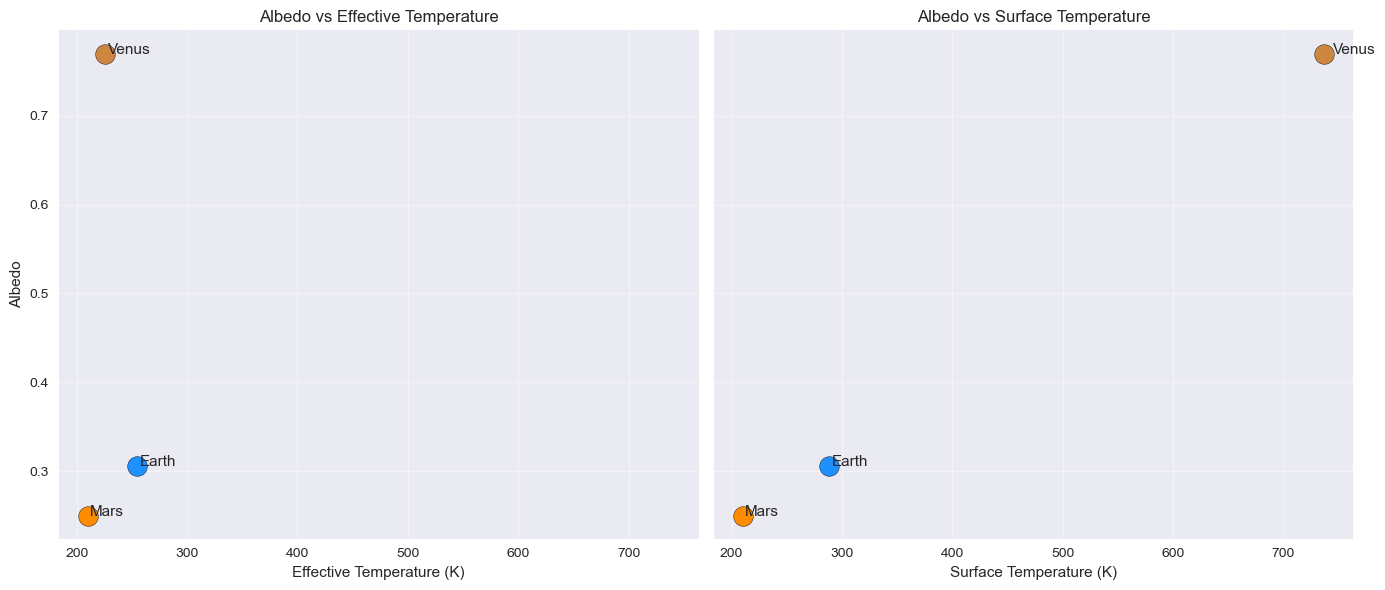

In [16]:
colors = {
    "Mars": "darkorange",
    "Earth": "dodgerblue",
    "Venus": "peru"   # permanently assigning colors to planet names
}

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True, sharex = True)

# --- LEFT SUBPLOT: Albedo vs Effective Temperature ---
ax = axes[0]
for planet, row in planet_constants.set_index("planet").iterrows():
    ax.scatter(
        row["effective_temp_K"],
        row["albedo"],
        s=200,
        color=colors[planet],
        edgecolor="black"
    )
    ax.text(
        row["effective_temp_K"] * 1.01,
        row["albedo"],
        planet,
        fontsize=11
    )

ax.set_xlabel("Effective Temperature (K)")
ax.set_ylabel("Albedo")
ax.set_title("Albedo vs Effective Temperature")
ax.grid(True, alpha=0.4)

"""
Plot albedo vs effective temp, then against surface temp (actual)
wanted to use the planet constant dataframe so this is a subplot
The overall idea is to have the closest thing possible to a before-and-after (or expectation vs reality) sort of demonstration. 
So this left plot is against the effective temperature, or what we'd expect to be the temperature if the greenhouse gas effect didn't occur.
The right plot will be against the actual temperature and demonstrate the near-linear correlation between albedo and surface temperature.
This is also a kind of rudimentary evidence of the feedback loop between albedo and temperature and how that then culminates in the runaway
greenhouse gas effect on Venus.
"""
# --- RIGHT SUBPLOT: Albedo vs Surface Temperature ---
ax = axes[1]
for planet, row in planet_constants.set_index("planet").iterrows():
    ax.scatter(
        row["surface_temp_K"],
        row["albedo"],
        s=200,
        color=colors[planet],
        edgecolor="black"
    )
    ax.text(
        row["surface_temp_K"] * 1.01,
        row["albedo"],
        planet,
        fontsize=11
    )

ax.set_xlabel("Surface Temperature (K)")
ax.set_title("Albedo vs Surface Temperature")
ax.grid(True, alpha=0.4)

plt.tight_layout()
# plt.savefig('final_project_albedo_subplots.png') # once again commented out, but:
# trying to save the plot as a png to avoid getting a grainy screenshot in our slides.
plt.show()

I should note that we tried a bunch of variable combinations by use the same general plt.scatter or plt.plot for the two dataframes (especially in regards to our subplost) but we chose these versions to show as our final project because we thought the said the most about our data. I should also point out that we totally added emissivity and then didn't use it, we found in our plots that albedo and emissivity were very similar in the plots in that they are kind of opposites so we felt having both was redundant and that albedo was better overall.